# Returns, Losses, and Financial Risk

Notebook 04 described empirical distributions and comparisons with parametric models. Here, a distribution describes possible returns. A risk measure summarizes a particular aspect of the corresponding losses. Value at Risk locates a loss threshold, while Expected Shortfall describes the average loss beyond it.

I use simulations from known distributions to compare population risk with estimates from finite samples. Observations are iid over a fixed hypothetical horizon. Actual market data are introduced in Notebook 06.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from scipy.integrate import quad
from finstats.nonparametric import empirical_cdf
from finstats.risk import (
    historical_var, historical_es, gaussian_var, gaussian_es, student_t_var, student_t_es,
)
from finance_statistical_methods.returns.returns import simple_returns, log_returns
from finance_statistical_methods.distributions.univariate import normal, student_t

## 1. Returns and losses

A simple price return and log return are
$$R_t=\frac{P_t-P_{t-1}}{P_{t-1}},\qquad
r_t=\log(P_t/P_{t-1})=\log(1+R_t).$$
They are close for small changes but differ for large ones. Dividends must be included separately if the price series does not already reflect them.

For a generic return variable $R$, define $L=-R$. A negative return is a positive loss, which retains the return's horizon and units. For a continuous return distribution,
$$F_L(l)=P(R\ge-l)=1-F_R(-l),\qquad f_L(l)=f_R(-l).$$
Negation reflects the density and reverses asymmetry.

For initial wealth $V_0$, the monetary loss is $-V_0R$ for a simple return. For a log return it is $V_0(1-e^r)$, which is not exactly $-V_0r$. The risk examples specify losses directly, with percentage-point or standardized units stated for each illustration. These losses are not presented as exact monetary losses from log returns.

For illustration, I use the price observations 100, 105, 101, and 108 to show the two return definitions.

In [2]:
illustrative_prices = np.array([100., 105., 101., 108.])
display(pd.DataFrame({"simple return (%)": 100*simple_returns(illustrative_prices),
                      "log return (%)": 100*log_returns(illustrative_prices)}).round(4))

,simple return (%),log return (%)
0,5.0000,4.8790
1,-3.8095,-3.8840
2,6.9307,6.7011


## 2. Value at Risk and Expected Shortfall

I use $\alpha$ for the upper-tail probability rather than the confidence level. Value at Risk is
$$VaR_\alpha=F_L^{-1}(1-\alpha).$$
Thus 1% VaR is the 99th loss percentile. It is a threshold rather than a maximum possible loss. For a continuous distribution, $P(L>VaR_\alpha)=\alpha$.

Expected Shortfall is the conditional tail mean, when finite:
$$ES_\alpha=E[L\mid L>VaR_\alpha]
=\frac1\alpha\int_{VaR_\alpha}^\infty l f_L(l)\,dl.$$
For a continuous distribution it also equals
$$ES_\alpha=\frac1\alpha\int_{1-\alpha}^1F_L^{-1}(q)\,dq.$$
The equivalence follows by substituting $q=F_L(l)$. For distributions with atoms, boundary probability must be handled explicitly to preserve this integrated-quantile definition. The historical estimator below retains the course's strict-exceedance convention.

For illustration, I use Gaussian losses with mean zero and standard deviation two percentage points at $\alpha=0.05$. The shaded area is the exceedance probability. VaR marks where the tail begins, while ES marks its average location. The population formulas are derived next.

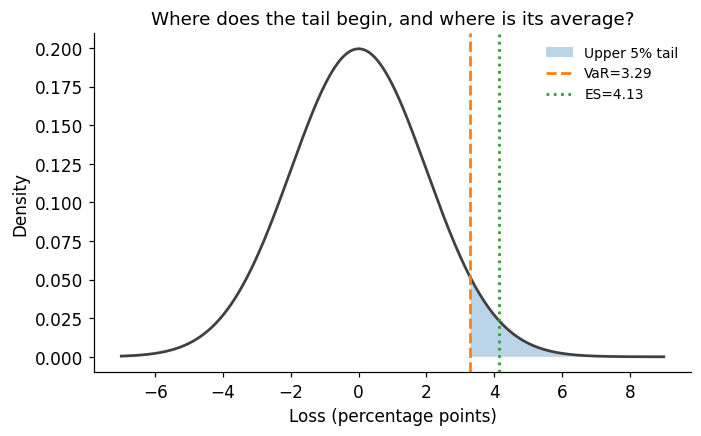

In [3]:
loss_distribution = stats.norm(loc=0, scale=2)
alpha = .05
threshold = loss_distribution.ppf(1-alpha)
tail_average = quad(lambda x: x*loss_distribution.pdf(x), threshold, np.inf)[0]/alpha
loss_grid = np.linspace(-7, 9, 1001)
fig, ax = plt.subplots()
ax.plot(loss_grid, loss_distribution.pdf(loss_grid), color="0.25")
ax.fill_between(loss_grid, loss_distribution.pdf(loss_grid), where=loss_grid>=threshold,
                alpha=.3, label="Upper 5% tail")
ax.axvline(threshold, color="C1", linestyle="--", label=f"VaR={threshold:.2f}")
ax.axvline(tail_average, color="C2", linestyle=":", label=f"ES={tail_average:.2f}")
ax.set(xlabel="Loss (percentage points)", ylabel="Density", title="Where does the tail begin, and where is its average?")
ax.legend(fontsize=9)
plt.show()

## 3. Parametric population risk

### Gaussian losses

For $L=\mu_L+\sigma_LZ$ with $Z\sim N(0,1)$ and $z=\Phi^{-1}(1-\alpha)$,
$$VaR_\alpha=\mu_L+\sigma_Lz.$$
Using $\phi'(u)=-u\phi(u)$ gives
$$\int_z^\infty u\phi(u)\,du=\phi(z),\qquad
ES_\alpha=\mu_L+\sigma_L\frac{\phi(z)}\alpha.$$
The same formula applies to fitted Gaussian losses after substituting parameter estimates. Known parameters give a population quantity, while estimated parameters give an estimate.

### Student-t losses

For $L=m+\lambda T_\nu$, with $t=t_{1-\alpha,\nu}$,
$$VaR_\alpha=m+\lambda t.$$
Integrating the standard density, using its power form from Notebook 01, gives
$$\int_t^\infty u f_{t_\nu}(u)\,du=\frac{\nu+t^2}{\nu-1}f_{t_\nu}(t),$$
so
$$ES_\alpha=m+\lambda\frac{\nu+t^2}{\nu-1}\frac{f_{t_\nu}(t)}\alpha,\qquad\nu>1.$$
A quantile exists for every $\nu>0$, but finite ES requires $\nu>1$. At $\nu=2$, ES is finite even though variance is infinite. Scale $\lambda$ is not the standard deviation.

### Comparing tail shape at equal variance

For illustration, I compare Gaussian, Student-$t_5$, Laplace, and skew-normal losses at mean zero and variance one. The Student-t scale is $\sqrt{3/5}$, Laplace scale is $1/\sqrt2$, and skew-normal shape is three before centering and standardizing. Here losses are expressed in common standard-deviation units, rather than the percentage-point units used in the opening example. I calculate population VaR and ES at 5% and 1%. For Laplace and skew-normal, the displayed integral definition is evaluated numerically, rather than adding another closed-form risk API.
The vertical axis of the tail figure is logarithmic: equal vertical distances represent multiplicative changes in exceedance probability. This makes differences between very small tail probabilities visible. The horizontal axis measures losses in the common standard-deviation units.


,family,alpha,VaR,ES
0,Gaussian,0.05,1.6449,2.0627
1,Gaussian,0.01,2.3263,2.6652
2,Student-t₅,0.05,1.5608,2.2387
3,Student-t₅,0.01,2.6065,3.4488
4,Laplace,0.05,1.6282,2.3353
5,Laplace,0.01,2.7662,3.4733
6,Skew-normal,0.05,1.8409,2.4191
7,Skew-normal,0.01,2.7834,3.2671


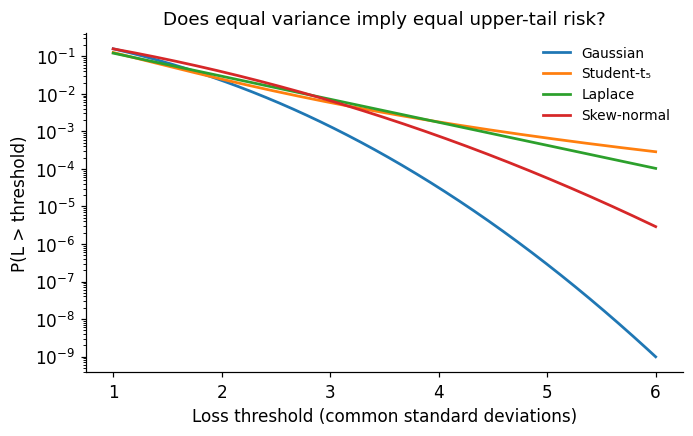

In [4]:
skew_mean, skew_variance = stats.skewnorm.stats(3, moments="mv")
loss_populations = {
    "Gaussian": stats.norm(),
    "Student-t₅": stats.t(5, scale=np.sqrt(3/5)),
    "Laplace": stats.laplace(scale=1/np.sqrt(2)),
    "Skew-normal": stats.skewnorm(3, loc=-skew_mean/np.sqrt(skew_variance), scale=1/np.sqrt(skew_variance)),
}
population_rows = []
for name, distribution in loss_populations.items():
    for alpha in (.05, .01):
        if name == "Gaussian":
            var, es = gaussian_var(0, 1, alpha), gaussian_es(0, 1, alpha)
        elif name == "Student-t₅":
            var, es = student_t_var(0, np.sqrt(3/5), 5, alpha), student_t_es(0, np.sqrt(3/5), 5, alpha)
        else:
            var = distribution.isf(alpha)
            es = quad(lambda x: x*distribution.pdf(x), var, np.inf)[0]/alpha
        population_rows.append({"family": name, "alpha": alpha, "VaR": var, "ES": es})
population_risk = pd.DataFrame(population_rows)
display(population_risk.round(4))
fig, ax = plt.subplots()
tail_grid = np.linspace(1, 6, 601)
for name, distribution in loss_populations.items():
    ax.semilogy(tail_grid, distribution.sf(tail_grid), label=name)
ax.set(xlabel="Loss threshold (common standard deviations)", ylabel="P(L > threshold)",
       title="Does equal variance imply equal upper-tail risk?")
ax.legend(fontsize=9)
plt.show()

Equal mean and variance do not determine tail risk. The upper-tail comparison also depends on the direction of asymmetry. A skew-normal loss example need not have the same interpretation as a skew-normal return example, because negation reverses its shape.

## 4. Historical risk estimates

Observed losses give the inverse-ECDF threshold
$$\widehat{VaR}_\alpha=\hat F_{L,n}^{-1}(1-\alpha).$$
The course's historical ES estimator averages losses strictly above it:
$$\widehat{ES}_\alpha=
\frac{\sum_iL_iI(L_i>\widehat{VaR}_\alpha)}{\sum_iI(L_i>\widehat{VaR}_\alpha)}.$$
**Convention note.** This strict-exceedance average differs from integrated empirical ES, which can assign fractional weight at the quantile boundary. Its tail count need not equal $n\alpha$, and it is undefined if there are no exceedances.

For illustration, I retain the course's loss population $L=5+2T_\nu$ with $(\nu,n)=(2,250),(20,250),(2,2500)$ and $\alpha=0.005$, using seed 415. The same threshold probability is estimated from populations with different tail shapes and sample sizes. The plots focus on the upper tail, with true and estimated risk values printed below.

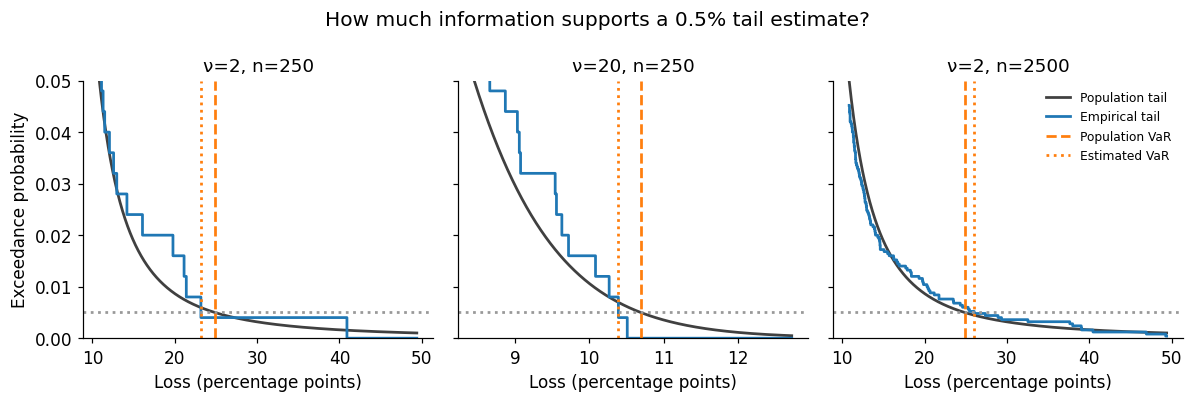

,df,n,true VaR,estimated VaR,true ES,estimated ES,strict tail count
0,2,250,24.8497,23.1611,44.8999,40.8992,1
1,20,250,10.6907,10.3893,11.5688,10.5095,1
2,2,2500,24.8497,26.0244,44.8999,40.3753,12


In [5]:
rng_tail = np.random.default_rng(415)
tail_rows = []
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
for ax, (df, n) in zip(axes, ((2, 250), (20, 250), (2, 2500))):
    losses = 5+2*rng_tail.standard_t(df, size=n)
    true_var = student_t_var(5, 2, df, .005)
    true_es = student_t_es(5, 2, df, .005)
    estimate_var = historical_var(losses, .005)
    estimate_es = historical_es(losses, .005)
    grid = np.linspace(stats.t.ppf(.95, df, loc=5, scale=2), max(true_es, estimate_es)*1.1, 1001)
    ax.plot(grid, stats.t.sf(grid, df, loc=5, scale=2), color="0.25", label="Population tail")
    ax.step(grid, 1-empirical_cdf(losses)(grid), where="post", label="Empirical tail")
    ax.axhline(.005, color="0.6", linestyle=":")
    ax.axvline(true_var, color="C1", linestyle="--", label="Population VaR")
    ax.axvline(estimate_var, color="C1", linestyle=":", label="Estimated VaR")
    ax.set(xlabel="Loss (percentage points)", title=f"ν={df}, n={n}", ylim=(0, .05))
    tail_rows.append({"df": df, "n": n, "true VaR": true_var, "estimated VaR": estimate_var,
                      "true ES": true_es, "estimated ES": estimate_es,
                      "strict tail count": np.count_nonzero(losses>estimate_var)})
axes[0].set_ylabel("Exceedance probability")
axes[-1].legend(fontsize=8)
fig.suptitle("How much information supports a 0.5% tail estimate?")
fig.tight_layout()
plt.show()
display(pd.DataFrame(tail_rows).round(4))

At $n=250$, this tail estimate uses only one strict exceedance. ES then equals that single observed loss. More observations improve tail resolution, but a close estimate from one sample is not evidence that the procedure is reliable.

## 5. Sampling variability in risk estimates

For illustration, I generate 500 independent samples at $n=250$ and $2500$ from a unit-variance Student-$t_5$ loss population, using seed 505. Losses are expressed in standard-deviation units, as in the equal-variance comparison. At 1% tail probability, I compare estimated VaR and ES with their fixed population values. The histograms describe estimator distributions across samples, rather than distributions of individual losses.

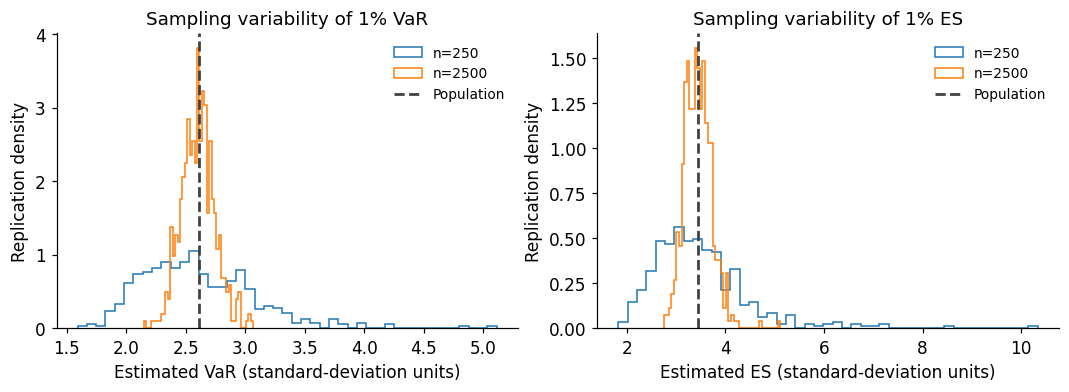

,n,measure,population,mean estimate,replication SD
0,250,VaR,2.6065,2.6024,0.4726
1,250,ES,3.4488,3.4651,0.9529
2,2500,VaR,2.6065,2.6033,0.1416
3,2500,ES,3.4488,3.4469,0.2767


In [6]:
rng_replications = np.random.default_rng(505)
alpha = .01
true_var = student_t_var(0, np.sqrt(3/5), 5, alpha)
true_es = student_t_es(0, np.sqrt(3/5), 5, alpha)
risk_replications = {}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
replication_rows = []
for n in (250, 2500):
    draws = loss_populations["Student-t₅"].rvs(size=(500, n), random_state=rng_replications)
    estimates = np.array([[historical_var(row, alpha), historical_es(row, alpha)] for row in draws])
    risk_replications[n] = estimates
    for j, (ax, name, truth) in enumerate(zip(axes, ("VaR", "ES"), (true_var, true_es))):
        ax.hist(estimates[:, j], bins=45, density=True, histtype="step", label=f"n={n}")
        replication_rows.append({"n": n, "measure": name, "population": truth,
                                 "mean estimate": estimates[:,j].mean(), "replication SD": estimates[:,j].std(ddof=1)})
for ax, name, truth in zip(axes, ("VaR", "ES"), (true_var, true_es)):
    ax.axvline(truth, color="0.25", linestyle="--", label="Population")
    ax.set(xlabel=f"Estimated {name} (standard-deviation units)", ylabel="Replication density", title=f"Sampling variability of 1% {name}")
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
display(pd.DataFrame(replication_rows).round(4))

ES depends on the magnitudes of the most extreme observations, which makes it especially sensitive to a sparse tail. Larger samples narrow the estimator distributions in this experiment. The population is known here, while real observations provide no true risk value for comparison.

More observations reduce sampling variability, but do not correct an inappropriate parametric assumption. Notebook 06 applies empirical and parametric risk descriptions to market observations, where the true distribution and population risk measures are unknown.
